In [1]:
import warnings
import numpy as np
import bambi as bmb
import arviz as az
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)

from utils import data

In [2]:
cluster_df = data.load_cluster_features()
cluster_df = cluster_df.to_pandas()

In [3]:
cluster_df.columns

Index(['window_id', 'window_idx', 'wn_mid_date', 'wn_prop_sequenced',
       'log_seq_prop', 'cluster_id', 'n_sequences', 'n_sequences_minus_one',
       'median_age', 'age_diversity', 'frac_female', 'frac_vaccinated',
       'simd_decile_mode', 'simd_decile_std', 'simd_quintile_mode',
       'simd_quintile_std', 'overall_zscore', 'income_zscore',
       'employment_zscore', 'education_zscore', 'health_zscore',
       'access_zscore', 'crime_zscore', 'housing_zscore', 'pango_lineage',
       'who_voc', 'qc_frac_mediocre', 'qc_frac_bad', 'wave'],
      dtype='object')

In [6]:
model_data = cluster_df.iloc[:5000, :].copy()

In [7]:
# Separate linear predictors for each component
formula_separate = """
    n_sequences_minus_one ~
    log_seq_prop +
    wave +
    median_age +
    age_diversity +
    frac_female +
    frac_vaccinated * wave +
    C(simd_quintile_mode, Treatment(3)) +
    simd_quintile_std +
    (1 | pango_lineage) |
    psi ~ wave + frac_vaccinated + C(simd_quintile_mode, Treatment(3))
"""

# Include all clusters, singletons (0) and non-singletons
formula = """
    n_sequences_minus_one ~
    log_seq_prop +
    wave +
    median_age +
    age_diversity +
    frac_female +
    frac_vaccinated * wave +
    C(simd_quintile_mode, Treatment(3)) +
    simd_quintile_std +
    (1 | pango_lineage)
"""

model = bmb.Model(
    formula,
    data=model_data,        # all clusters including singletons
    family="hurdle_negativebinomial",
    dropna=True,
)

# model_data['size_cat'] = pd.cut(
#     model_data['n_sequences_minus_one'],
#     bins=[-1, 0, 1, 5, 20, 100, np.inf],
#     labels=['singleton', 'small', 'medium',
#             'large', 'very_large', 'outbreak']
# )
#
# model = bmb.Model(
#     formula.replace("n_sequences_minus_one", "size_cat"),
#     data=model_data,
#     family="cumulative",
#     dropna=True,
# )

model.build()


In [ ]:
idata = model.fit(
    random_seed=42,
    idata_kwargs = {"log_likelihood": True},  # needed for model comparison
    cores=1,
)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [psi, alpha, Intercept, log_seq_prop, wave, median_age, age_diversity, frac_female, frac_vaccinated, frac_vaccinated:wave, C(simd_quintile_mode, Treatment(3)), simd_quintile_std, 1|pango_lineage_sigma, 1|pango_lineage_offset]


Output()

In [36]:
all_vars = list(idata.posterior.data_vars)
summary = az.summary(idata, round_to=3)
display(summary)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-0.611,0.176,-0.953,-0.293,0.003,0.002,2898.745,3961.822,1.000
log_seq_prop,0.188,0.043,0.107,0.266,0.001,0.000,6114.953,5888.674,1.000
"C(dz_simd_quintile, Treatment(3))[1]",0.039,0.102,-0.148,0.235,0.002,0.001,2605.899,4122.534,1.001
"C(dz_simd_quintile, Treatment(3))[2]",0.193,0.106,-0.009,0.391,0.002,0.001,2674.202,4650.526,1.001
"C(dz_simd_quintile, Treatment(3))[4]",0.062,0.110,-0.134,0.277,0.002,0.001,2916.113,4954.798,1.001
"C(dz_simd_quintile, Treatment(3))[5]",0.090,0.117,-0.142,0.298,0.002,0.001,2990.711,4782.876,1.001
wave[WV2_B.1.1.7_C574152],-0.603,0.134,-0.841,-0.333,0.002,0.001,3158.763,4140.283,1.001
wave[WV3_AY.4_C983568],-0.178,0.128,-0.413,0.063,0.002,0.001,3167.545,4666.660,1.000
wave[WV4_BA.2_C479360],-0.413,0.127,-0.655,-0.181,0.002,0.001,3242.658,4675.507,1.000
wave[WV5_BA.2_C85080],0.568,0.229,0.126,0.993,0.003,0.003,4623.164,4776.778,1.000


In [37]:
# Flag any convergence problems
rhat_max = summary["r_hat"].max()
ess_min  = summary[["ess_bulk", "ess_tail"]].min().min()
divs     = idata.sample_stats["diverging"].values.sum()
if rhat_max > 1.01 or ess_min < 400 * CHAINS:
    print("\nConvergence concerns — consider increasing DRAWS/TUNE "
          "or raising target_accept.")
if divs > 0:
    print(f"\n{int(divs)} divergences — try raising target_accept "
          "or reparameterising priors.")

In [38]:
# ── Interpreting kappa ─────────────────────────────────────────────────────
#
# kappa is the Beta concentration parameter:
#   kappa < 5   → substantial overdispersion relative to Binomial
#   kappa ~= ∞  → model collapses to Binomial (no extra variance)
#
# A useful alternative: compute the overdispersion ratio
# Var_BetaBinom / Var_Binom = 1 + (n-1)/(kappa+1)  [approx for fixed n]

kappa_posterior = idata.posterior["kappa"].values.flatten()
kappa_median = np.median(kappa_posterior)
typical_n    = model_data[TRIALS_COL].median()
od_ratio     = 1 + (typical_n - 1) / (kappa_median + 1)

print(f"\nkappa (median):     {kappa_median:.2f}")
print(f"Overdispersion ratio (at median n={typical_n:.0f}): {od_ratio:.2f}x Binomial variance")


kappa (median):     1.49
Overdispersion ratio (at median n=24): 10.22x Binomial variance



PPC plots saved to ppc_checks.png


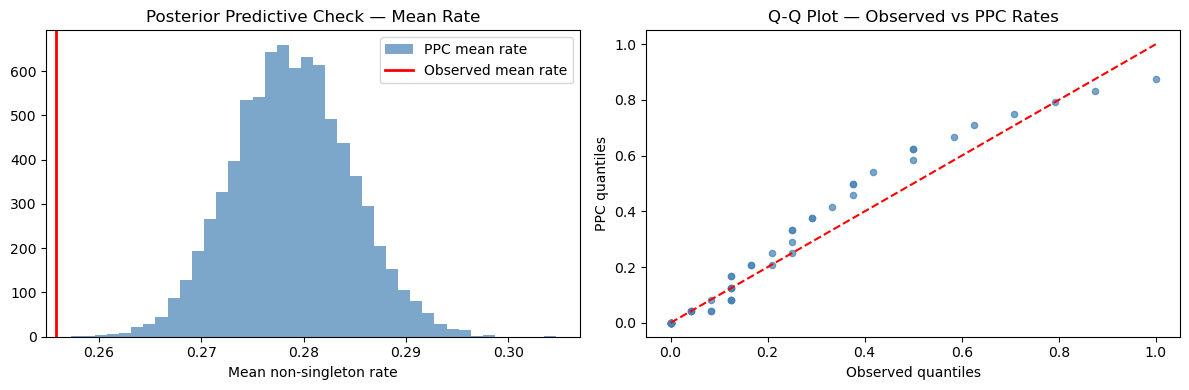

In [39]:
# ── Posterior predictive check ─────────────────────────────────────────────
model.predict(idata, kind="response", random_seed=RANDOM_SEED)

obs_rates  = model_data[OUTCOME] / model_data[TRIALS_COL]
ppc_counts = idata.posterior_predictive[PPC_KEY].values  # <-- was [OUTCOME]
ppc_rates  = ppc_counts / model_data[TRIALS_COL].values[np.newaxis, np.newaxis, :]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (a) Distribution of mean rate
ppc_mean_rate = ppc_rates.reshape(-1, len(model_data)).mean(axis=1)
axes[0].hist(ppc_mean_rate, bins=40, color="steelblue", alpha=0.7,
             label="PPC mean rate")
axes[0].axvline(obs_rates.mean(), color="red", lw=2, label="Observed mean rate")
axes[0].set_xlabel("Mean non-singleton rate")
axes[0].set_title("Posterior Predictive Check — Mean Rate")
axes[0].legend()

# (b) Observed vs predicted quantiles
q_obs = np.quantile(obs_rates, np.linspace(0.05, 0.95, 50))
q_ppc = np.quantile(ppc_rates.reshape(-1), np.linspace(0.05, 0.95, 50))
axes[1].scatter(q_obs, q_ppc, s=20, alpha=0.7, color="steelblue")
lims = [min(q_obs.min(), q_ppc.min()), max(q_obs.max(), q_ppc.max())]
axes[1].plot(lims, lims, "r--", lw=1.5)
axes[1].set_xlabel("Observed quantiles")
axes[1].set_ylabel("PPC quantiles")
axes[1].set_title("Q-Q Plot — Observed vs PPC Rates")

plt.tight_layout()
# plt.savefig("ppc_checks.png", dpi=150)
print("\nPPC plots saved to ppc_checks.png")

In [ ]:
idata.to_netcdf("beta_binomial_trace.nc")
print("\nFull trace saved to beta_binomial_trace.nc")
print("Reload later with:  az.from_netcdf('beta_binomial_trace.nc')")